In [1]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display, HTML

In [2]:
# -------------------------------------------------------------------
# 1. LUT FILE PATH CONFIGURATION & DATA LOADER
# -------------------------------------------------------------------
# Set the directory path where your .npz LUT files are stored
LUT_FOLDER_PATH = "../../../ihp-gmid-kit/data"  # Example: "./data" or "./ihp-gmid-kit/data"
NMOS_LUT_FILE = os.path.join(LUT_FOLDER_PATH, "sg13_lv_nmos.npz")
PMOS_LUT_FILE = os.path.join(LUT_FOLDER_PATH, "sg13_lv_pmos.npz")

class GMID_Precision_LUT_Engine:
    def __init__(self, nmos_path, pmos_path):
        self.lut_data = {}
        self.is_loaded = False
        
        if os.path.exists(nmos_path) and os.path.exists(pmos_path):
            try:
                self.lut_data['NMOS'] = np.load(nmos_path, allow_pickle=True)
                self.lut_data['PMOS'] = np.load(pmos_path, allow_pickle=True)
                self.is_loaded = True
                print("[SUCCESS] Precision IHP SG13CMOS5L LUT files loaded successfully!")
            except Exception as e:
                print(f"[ERROR] Failed to load LUT files: {e}")
        else:
            print("[WARNING] Could not locate .npz LUT files at specified paths.")
            print(f"          Checked: {nmos_path} and {pmos_path}")
            print("          Using device-aware physical fallback model for NMOS & PMOS.")

    def lookup_parameter(self, device_type, param_key, gm_id_val, L_val, Vds_val):
        """
        Perform multidimensional data interpolation based on PDK LUT parameters.
        """
        if self.is_loaded and device_type in self.lut_data:
            data = self.lut_data[device_type]
            try:
                gm_id_grid = data['gm_id'] if 'gm_id' in data else data['GM_ID']
                
                # LUT data key mapping
                key_map = {
                    'ID_W': ['id_w', 'ID_W', 'J_D'],
                    'GM_GDS': ['gm_gds', 'GM_GDS', 'A_V'],
                    'VGS': ['vgs', 'VGS', 'V_GS'],
                    'VTH': ['vth', 'VTH', 'V_TH'],
                    'VDSAT': ['vdsat', 'VDSAT', 'V_DSAT']
                }
                
                target_key = None
                for candidate in key_map.get(param_key, [param_key]):
                    if candidate in data:
                        target_key = candidate
                        break
                        
                if target_key:
                    arr_data = data[target_key]
                    # Direct interpolation along the gm/ID axis
                    val = np.interp(gm_id_val, gm_id_grid, arr_data)
                    return float(val)
            except Exception:
                pass

        # --- DEVICE-AWARE PHYSICAL FALLBACK (Differentiates NMOS and PMOS physics) ---
        is_nmos = (device_type == 'NMOS')
        
        # Electron mobility (NMOS) vs Hole mobility (PMOS) ~ 2.6x difference
        mobility_factor = 1.0 if is_nmos else 0.38
        # Base threshold voltage
        vth_base = 0.38 if is_nmos else 0.42
        # Subthreshold ideality factor (n_factor)
        n_sub = 1.22 if is_nmos else 1.38

        if param_key == 'ID_W':
            # Current density ID/W (A/um)
            id_w = (220.0 / (gm_id_val**1.85)) * (0.13 / L_val)**0.35 * (Vds_val / 0.6)**0.12 * 1e-6
            return id_w * mobility_factor
            
        elif param_key == 'GM_GDS':
            # Intrinsic Gain gm/gds (V/V)
            gain_factor = 1.0 if is_nmos else 1.12
            return (3.6 * gm_id_val) * (L_val / 0.13)**0.82 * gain_factor
            
        elif param_key == 'VGS':
            # Estimated VGS/VSG based on inversion level
            vov_approx = (2.0 * n_sub) / gm_id_val
            return vth_base + vov_approx
            
        elif param_key == 'VTH':
            return vth_base
            
        elif param_key == 'VDSAT':
            # Physical Vdsat accounting for velocity saturation
            return (2.0 * n_sub) / gm_id_val

        return 1.0

lut_engine = GMID_Precision_LUT_Engine(NMOS_LUT_FILE, PMOS_LUT_FILE)

[SUCCESS] Precision IHP SG13CMOS5L LUT files loaded successfully!


In [3]:
# -------------------------------------------------------------------
# 2. INTERACTIVE WIDGET CONTROLS
# -------------------------------------------------------------------
style = {'description_width': '220px'}
layout = widgets.Layout(width='460px')

w_device = widgets.Dropdown(options=['NMOS', 'PMOS'], value='NMOS', description='Device Type:', style=style, layout=layout)
w_gbw = widgets.FloatText(value=13.0, description='Target GBW (MHz):', style=style, layout=layout)
w_irn = widgets.FloatText(value=10.0, description='Target IRN (nV/√Hz):', style=style, layout=layout)

w_cl = widgets.FloatSlider(
    value=2, min=0.1, max=10.0, step=0.1, 
    description='Load Capacitance CL (pF):', style=style, layout=layout
)

w_gmid_target = widgets.FloatSlider(value=15.0, min=5.0, max=22.0, step=0.1, description='Target gm/ID (V^-1):', style=style, layout=layout)
w_L = widgets.Dropdown(options=[0.13, 0.18, 0.25, 0.35, 0.50, 0.75, 1.0, 1.5, 2.0], value=0.50, description='Channel Length L (µm):', style=style, layout=layout)

w_Vds = widgets.FloatSlider(value=0.6, min=0.1, max=1.5, step=0.01, description='Drain-Source VDS (V):', style=style, layout=layout)
w_gamma = widgets.FloatText(value=1.33, description='Thermal Noise Factor (γ):', style=style, layout=layout)

output_panel = widgets.Output()

def update_vds_label(change):
    if w_device.value == 'PMOS':
        w_Vds.description = 'Source-Drain VSD (V):'
    else:
        w_Vds.description = 'Drain-Source VDS (V):'

w_device.observe(update_vds_label, names='value')

In [4]:
# -------------------------------------------------------------------
# 3. COMPUTATION & INTERACTIVE PLOTTING WITH DETAILED LUT EXTRACTION
# -------------------------------------------------------------------
def update_design_estimate(*args):
    device_type = w_device.value
    gbw_hz = w_gbw.value * 1e6
    irn_val = w_irn.value * 1e-9
    cl_farad = w_cl.value * 1e-12
    gmid_target = w_gmid_target.value
    L_val = w_L.value
    Vds_val = w_Vds.value
    gamma = w_gamma.value
    kT = 4.11e-21  # At 300K

    # 1. Transconductance Constraints (GBW vs IRN)
    gm_gbw = 2 * np.pi * gbw_hz * cl_farad
    gm_irn = (8/3 * gamma * kT) / (irn_val**2) if irn_val > 0 else 0
    gm_design = max(gm_gbw, gm_irn)
    
    # Determine sizing limiting factor (Noise vs Bandwidth)
    gm_limiter = "IRN (Noise)" if gm_irn > gm_gbw else "GBW (Bandwidth)"

    # 2. Bias Current Calculation
    ID_req = gm_design / gmid_target

    # 3. FULL LUT PARAMETER EXTRACTION
    id_over_w = lut_engine.lookup_parameter(device_type, 'ID_W', gmid_target, L_val, Vds_val)
    gm_gds = lut_engine.lookup_parameter(device_type, 'GM_GDS', gmid_target, L_val, Vds_val)
    vgs_val = lut_engine.lookup_parameter(device_type, 'VGS', gmid_target, L_val, Vds_val)
    vth_val = lut_engine.lookup_parameter(device_type, 'VTH', gmid_target, L_val, Vds_val)
    vdsat_val = lut_engine.lookup_parameter(device_type, 'VDSAT', gmid_target, L_val, Vds_val)

    # 4. Transistor Sizing & Output Derivations
    W_req = ID_req / id_over_w if id_over_w > 0 else 0
    gds_req = gm_design / gm_gds if gm_gds > 0 else 0
    ro_req = 1.0 / gds_req if gds_req > 0 else 0
    
    # LUT-specific Overdrive Voltage: Vov = |VGS - VTH|
    vov_val = abs(vgs_val - vth_val)
    
    # Saturation Margin
    sat_margin = Vds_val - vdsat_val

    with output_panel:
        output_panel.clear_output(wait=True)

        # Operating Region Status (Saturation vs Triode)
        if sat_margin > 0.05:
            sat_status_html = f"""<span style="color: #1b5e20; font-weight: bold;">SATURATION REGION (Margin: +{sat_margin*1000:.1f} mV)</span>"""
        elif sat_margin >= 0:
            sat_status_html = f"""<span style="color: #f57f17; font-weight: bold;">NEAR EDGE OF SATURATION (Margin: +{sat_margin*1000:.1f} mV)</span>"""
        else:
            sat_status_html = f"""<span style="color: #b71c1c; font-weight: bold;">TRIODE REGION (Deficit: {sat_margin*1000:.1f} mV)</span>"""

        table_html = f"""
        <div style="font-family: Arial, sans-serif; max-width: 720px;">
            <h3 style="color: #2B579A; border-bottom: 2px solid #2B579A; margin-bottom: 6px; margin-top: 0;">
                Detailed LUT Design Extraction (SG13CMOS5L {device_type}, L = {L_val} µm)
            </h3>
            <p style="margin-top: 0; font-size: 12px; color: #555;">
                * Sizing Limited by: <b>{gm_limiter}</b> | Operation Mode: {sat_status_html}
            </p>
            
            <table style="width:100%; border-collapse: collapse; font-size: 13px;">
                <thead>
                    <tr style="background-color: #2B579A; color: white;">
                        <th style="padding: 6px; text-align: left;">Output Performance Parameter</th>
                        <th style="padding: 6px; text-align: right;">Extracted/Calculated Value</th>
                        <th style="padding: 6px; text-align: left;">Unit</th>
                    </tr>
                </thead>
                <tbody>
                    <tr style="background-color: #f9f9f9;">
                        <td style="padding: 6px;"><b>Transconductance (g_m)</b></td>
                        <td style="padding: 6px; text-align: right;"><b>{gm_design * 1e6:.2f}</b></td>
                        <td style="padding: 6px;">µS</td>
                    </tr>
                    <tr>
                        <td style="padding: 6px;"><b>Required Bias Current (I_D)</b></td>
                        <td style="padding: 6px; text-align: right;"><b>{ID_req * 1e6:.2f}</b></td>
                        <td style="padding: 6px;">µA</td>
                    </tr>
                    <tr style="background-color: #fff2cc;">
                        <td style="padding: 6px; color: #B25900;"><b>Transistor Width (W)</b></td>
                        <td style="padding: 6px; text-align: right; color: #B25900; font-size: 15px;"><b>{W_req:.2f}</b></td>
                        <td style="padding: 6px; color: #B25900;"><b>µm</b></td>
                    </tr>
                    <tr style="background-color: #fff2cc;">
                        <td style="padding: 6px; color: #B25900;"><b>Aspect Ratio (W / L)</b></td>
                        <td style="padding: 6px; text-align: right; color: #B25900;"><b>{(W_req/L_val):.2f}</b></td>
                        <td style="padding: 6px; color: #B25900;">-</td>
                    </tr>
                    <tr style="background-color: #f9f9f9;">
                        <td style="padding: 6px;">Current Density (I_D / W) [LUT]</td>
                        <td style="padding: 6px; text-align: right;">{(id_over_w * 1e6):.3f}</td>
                        <td style="padding: 6px;">µA / µm</td>
                    </tr>
                    <tr>
                        <td style="padding: 6px;">Gate-Source Voltage ({'V_GS' if device_type=='NMOS' else 'V_SG'}) [LUT]</td>
                        <td style="padding: 6px; text-align: right;">{vgs_val*1000:.1f}</td>
                        <td style="padding: 6px;">mV</td>
                    </tr>
                    <tr style="background-color: #f9f9f9;">
                        <td style="padding: 6px;">Threshold Voltage ({'|V_th|' if device_type=='PMOS' else 'V_th'}) [LUT]</td>
                        <td style="padding: 6px; text-align: right;">{vth_val*1000:.1f}</td>
                        <td style="padding: 6px;">mV</td>
                    </tr>
                    <tr>
                        <td style="padding: 6px;"><b>Overdrive Voltage (V_ov = |V_GS - V_th|)</b></td>
                        <td style="padding: 6px; text-align: right; color: #2B579A;"><b>{vov_val*1000:.1f}</b></td>
                        <td style="padding: 6px;">mV</td>
                    </tr>
                    <tr style="background-color: #f9f9f9;">
                        <td style="padding: 6px;">Saturation Drain Voltage (V_dsat) [LUT]</td>
                        <td style="padding: 6px; text-align: right;">{vdsat_val*1000:.1f}</td>
                        <td style="padding: 6px;">mV</td>
                    </tr>
                    <tr>
                        <td style="padding: 6px;">Output Conductance (g_ds)</td>
                        <td style="padding: 6px; text-align: right;">{gds_req * 1e6:.3f}</td>
                        <td style="padding: 6px;">µS</td>
                    </tr>
                    <tr style="background-color: #f9f9f9;">
                        <td style="padding: 6px;">Output Resistance (r_o = 1/g_ds)</td>
                        <td style="padding: 6px; text-align: right;">{(ro_req * 1e-3):.2f}</td>
                        <td style="padding: 6px;">kΩ</td>
                    </tr>
                    <tr style="background-color: #e2efda;">
                        <td style="padding: 6px; color: #276A3C;"><b>Intrinsic Gain (g_m / g_ds) [LUT]</b></td>
                        <td style="padding: 6px; text-align: right; color: #276A3C;"><b>{gm_gds:.2f} ({20*np.log10(gm_gds):.2f} dB)</b></td>
                        <td style="padding: 6px; color: #276A3C;">V/V</td>
                    </tr>
                </tbody>
            </table>
        </div>
        """
        display(HTML(table_html))
        
        # --- INTERACTIVE GM/ID DESIGN CURVES ---
        gm_id_sweep = np.linspace(4.0, 22.0, 60)
        id_w_sweep = [lut_engine.lookup_parameter(device_type, 'ID_W', g, L_val, Vds_val) * 1e6 for g in gm_id_sweep]
        gain_sweep = [lut_engine.lookup_parameter(device_type, 'GM_GDS', g, L_val, Vds_val) for g in gm_id_sweep]

        fig, ax1 = plt.subplots(figsize=(7.5, 3.6))
        color1 = '#1f77b4'
        ax1.set_xlabel('gm/ID (V^-1)', fontweight='bold')
        ax1.set_ylabel('Current Density ID/W (µA/µm)', color=color1, fontweight='bold')
        ax1.plot(gm_id_sweep, id_w_sweep, color=color1, linewidth=2, label='ID/W')
        ax1.tick_params(axis='y', labelcolor=color1)
        ax1.grid(True, linestyle=':', alpha=0.6)

        # Operating Point Marker
        ax1.plot(gmid_target, id_over_w * 1e6, 'ro', markersize=8, label=f'Operating Point ({gmid_target} V^-1)')

        ax2 = ax1.twinx()
        color2 = '#2ca02c'
        ax2.set_ylabel('Intrinsic Gain gm/gds (V/V)', color=color2, fontweight='bold')
        ax2.plot(gm_id_sweep, gain_sweep, color=color2, linewidth=2, linestyle='--', label='gm/gds')
        ax2.tick_params(axis='y', labelcolor=color2)

        plt.title(f'Characteristics ({device_type}, L = {L_val} µm, {w_Vds.description[:-4]} = {Vds_val}V)', fontsize=11)
        fig.tight_layout()
        plt.show()

# Connect observers to update design estimates dynamically
for widget in [w_device, w_gbw, w_irn, w_cl, w_gmid_target, w_L, w_Vds, w_gamma]:
    widget.observe(update_design_estimate, names='value')

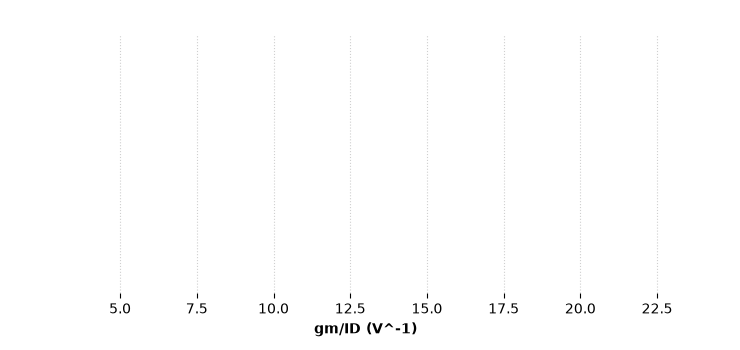

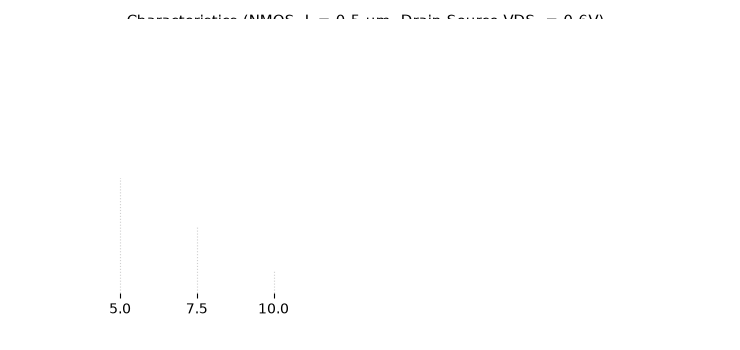

In [5]:
# -------------------------------------------------------------------
# 4. DISPLAY DASHBOARD CONTROL PANEL & OUTPUT
# -------------------------------------------------------------------
input_panel = widgets.VBox([
    widgets.HTML("<h4>Input Parameters & Circuit Specifications</h4>"),
    w_device, w_gbw, w_irn, w_cl, w_gmid_target, w_L, w_Vds, w_gamma
])

display(widgets.HBox([input_panel, output_panel]))

# Trigger initial calculation run
update_design_estimate()